In [74]:
# !pip install dfply

In [75]:
# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from dfply import *
from sklearn.metrics import mean_squared_log_error as msle
from datetime import timedelta
import os
import sys
from sklearn.model_selection import train_test_split


In [76]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [77]:
curr_path=os.getcwd()
chdir_path="/content/drive/MyDrive/Colab ""Notebooks/Project/NYC_Trip_Prediction"

In [78]:
del sys.modules['os']
print(curr_path)
if (curr_path!=chdir_path):
  os.chdir(chdir_path)

/content/drive/My Drive/Colab Notebooks/Project/NYC_Trip_Prediction


In [79]:
nyc_data=pd.read_csv("nyc_taxi_trip_duration.csv")

In [80]:
nyc_data.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


No null values seen

In [81]:
categorical=[var for var in nyc_data.columns if nyc_data[var].dtype=='O']
numerical=[var for var in nyc_data.columns if nyc_data[var].dtype!='O']
discrete=[var for var in numerical if nyc_data[var].nunique()<10]
continuous=[var for var in numerical if nyc_data[var].nunique()>10]

print('There are {} discrete variables'.format(len(discrete)))
print('There are {} continuous variables'.format(len(continuous)))
print('There are {} categorical variables'.format(len(categorical)))


There are 2 discrete variables
There are 5 continuous variables
There are 4 categorical variables


In [82]:
nyc_data['pickup_datetime']=pd.to_datetime(nyc_data['pickup_datetime'])
nyc_data['dropoff_datetime']=pd.to_datetime(nyc_data['dropoff_datetime'])

Removing outlier values in Trip Duration


In [83]:
nyc_data=nyc_data[(~(nyc_data.trip_duration==nyc_data['trip_duration'].max()) & ~(nyc_data.trip_duration==nyc_data['trip_duration'].min))]

Converting Trip Duration to a log transform


In [84]:
nyc_data['log_trip_duration']=np.log(nyc_data['trip_duration'].values+1)

<ipython-input-84-79db23d8eb8a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nyc_data['log_trip_duration']=np.log(nyc_data['trip_duration'].values+1)


<Axes: ylabel='log_trip_duration'>

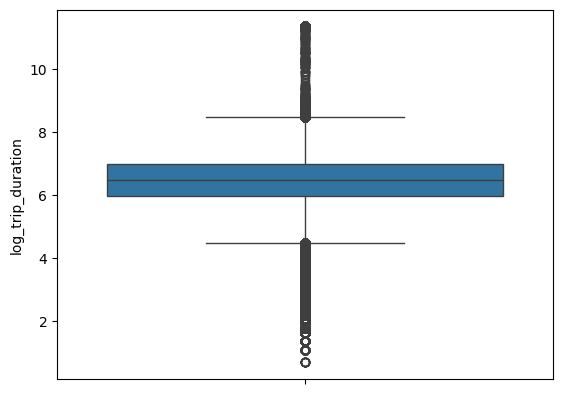

In [85]:
import seaborn as sns

sns.boxplot(nyc_data['log_trip_duration'])

Adding Weekday, Month, hour features, converting pickup_datetime as a date variable

In [128]:
nyc_data['WeekDay']=nyc_data['pickup_datetime'].dt.weekday
# 0 - Monday
nyc_data['Month']=nyc_data['pickup_datetime'].dt.month
nyc_data['hour']=nyc_data['pickup_datetime'].dt.hour
nyc_data['pickup_date']=nyc_data['pickup_datetime'].dt.date
nyc_data['pickup_minute'] = nyc_data['pickup_datetime'].dt.minute

In [127]:
def haversine_array(lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    AVG_EARTH_RADIUS = 6371  # in km
    lat = lat2 - lat1
    lng = lng2 - lng1
    d = np.sin(lat * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng * 0.5) ** 2
    h = 2 * AVG_EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h

def direction_array(lat1, lng1, lat2, lng2):
    AVG_EARTH_RADIUS = 6371  # in km
    lng_delta_rad = np.radians(lng2 - lng1)
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    return np.degrees(np.arctan2(y, x))




NameError: name 'df' is not defined

Dummy encoding the weekday variable

In [129]:
nyc_data['Weekday_cat']=nyc_data['WeekDay'].map({0:'Monday',1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6: 'Sunday'})

In [130]:
nyc_sub=nyc_data.drop(columns=['id','vendor_id','store_and_fwd_flag','trip_duration','passenger_count','pickup_datetime','dropoff_datetime','WeekDay','pickup_date'])

In [131]:
nyc_sub.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,log_trip_duration,Month,hour,Weekday_cat,pickup_minute
0,-73.953918,40.778873,-73.963875,40.771164,5.993961,2,16,Monday,40
1,-73.988312,40.731743,-73.994751,40.694931,7.003974,3,23,Friday,35
2,-73.997314,40.721458,-73.948029,40.774918,7.400010,2,17,Sunday,59
3,-73.961670,40.759720,-73.956779,40.780628,7.040536,1,9,Tuesday,44
4,-74.017120,40.708469,-73.988182,40.740631,6.744059,2,6,Wednesday,42


In [132]:
X_train, X_test, y_train, y_test= train_test_split(nyc_sub.drop(columns='log_trip_duration'),nyc_sub['log_trip_duration'],test_size=0.3, random_state=0)
X_train.shape,X_test.shape

((510524, 8), (218797, 8))

In [133]:
categorical=[var for var in X_train.columns if X_train[var].dtype=='O']
numerical=[var for var in X_train.columns if X_train[var].dtype!='O']
discrete=[var for var in numerical if X_train[var].nunique()<10]
continuous=[var for var in numerical if X_train[var].nunique()>10]

print('There are {} discrete variables'.format(len(discrete)))
print('There are {} continuous variables'.format(len(continuous)))
print('There are {} categorical variables'.format(len(categorical)))


There are 1 discrete variables
There are 6 continuous variables
There are 1 categorical variables


In [134]:
discrete

['Month']

In [135]:
X_train

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,Month,hour,Weekday_cat,pickup_minute
106299,-73.987740,40.748077,-73.981178,40.755863,5,21,Saturday,6
49732,-73.978470,40.719730,-73.958992,40.763538,3,23,Wednesday,52
287734,-73.994514,40.756001,-73.988106,40.753334,6,22,Sunday,45
15360,-73.941887,40.791279,-73.952820,40.817947,6,9,Saturday,23
107263,-73.975937,40.789120,-73.986816,40.771709,5,11,Friday,57
...,...,...,...,...,...,...,...,...
359784,-73.988609,40.731380,-73.995811,40.710331,6,15,Thursday,12
152316,-73.985771,40.741371,-73.993950,40.732040,6,8,Sunday,18
117953,-74.002159,40.748035,-73.993469,40.741417,4,17,Sunday,23
435830,-73.959328,40.763489,-73.966911,40.772335,2,16,Sunday,35


In [136]:
def find_limits(df, variable, fold):

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_limit = df[variable].quantile(0.25) - (IQR * fold)
    upper_limit = df[variable].quantile(0.75) + (IQR * fold)

    return lower_limit, upper_limit

lower_limit_lng, upper_limit_lng=find_limits(X_train,'pickup_longitude',2 )
lower_limit_lat, upper_limit_lat=find_limits(X_train,'pickup_latitude',2)
lower_limit_dlng, upper_limit_dlng=find_limits(X_train,'dropoff_longitude',2 )
lower_limit_dlat, upper_limit_dlat=find_limits(X_train,'dropoff_latitude',2)

In [137]:
X_train["pickup_longitude"].clip(lower=lower_limit_lng, upper=upper_limit_lng, inplace=True)
X_test["pickup_longitude"].clip(lower=lower_limit_lng, upper=upper_limit_lng, inplace=True)

X_train["pickup_latitude"].clip(lower=lower_limit_lat, upper=upper_limit_lat, inplace=True)
X_test["pickup_latitude"].clip(lower=lower_limit_lat, upper=upper_limit_lat, inplace=True)

X_train["dropoff_longitude"].clip(lower=lower_limit_dlng, upper=upper_limit_dlng, inplace=True)
X_test["dropoff_longitude"].clip(lower=lower_limit_dlng, upper=upper_limit_dlng, inplace=True)

X_train["dropoff_latitude"].clip(lower=lower_limit_dlat, upper=upper_limit_dlat, inplace=True)
X_test["dropoff_latitude"].clip(lower=lower_limit_dlat, upper=upper_limit_dlat, inplace=True)


<ipython-input-137-0f5d405fb30c>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["pickup_longitude"].clip(lower=lower_limit_lng, upper=upper_limit_lng, inplace=True)
<ipython-input-137-0f5d405fb30c>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing '

In [138]:

X_train['haversine_distance'] = haversine_array(X_train['pickup_latitude'].values,
                                                     X_train['pickup_longitude'].values,
                                                     X_train['dropoff_latitude'].values,
                                                     X_train['dropoff_longitude'].values)


X_train['direction'] = direction_array(X_train['pickup_latitude'].values,
                                          X_train['pickup_longitude'].values,
                                          X_train['dropoff_latitude'].values,
                                          X_train['dropoff_longitude'].values)

In [139]:
X_test['haversine_distance'] = haversine_array(X_test['pickup_latitude'].values,
                                                     X_test['pickup_longitude'].values,
                                                     X_test['dropoff_latitude'].values,
                                                     X_test['dropoff_longitude'].values)


X_test['direction'] = direction_array(X_test['pickup_latitude'].values,
                                          X_test['pickup_longitude'].values,
                                          X_test['dropoff_latitude'].values,
                                          X_test['dropoff_longitude'].values)

In [140]:
X_train.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,Month,hour,Weekday_cat,pickup_minute,haversine_distance,direction
106299,-73.987740,40.748077,-73.981178,40.755863,5,21,Saturday,6,1.027119,32.551995
49732,-73.978470,40.719730,-73.958992,40.763538,3,23,Wednesday,52,5.140196,18.610764
287734,-73.994514,40.756001,-73.988106,40.753334,6,22,Sunday,45,0.615881,118.776168
15360,-73.941887,40.791279,-73.952820,40.817947,6,9,Saturday,23,3.104902,-17.236215
107263,-73.975937,40.789120,-73.986816,40.771709,5,11,Friday,57,2.141723,-154.673939


In [141]:
import scipy.stats as stats

In [142]:
def diagnostic_plots(df, variable):

    # function to plot a histogram and a Q-Q plot
    # side by side, for a certain variable

    plt.figure(figsize=(15, 6))

    # histogram
    plt.subplot(1, 2, 1)
    df[variable].hist(bins=30)
    plt.title(f"Histogram of {variable}")

    # q-q plot
    plt.subplot(1, 2, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.title(f"Q-Q plot of {variable}")

    plt.show()

Since we are wanting to implement a linear regression , it is important that the predictor variables follow a normal distribution. Applying a log transform on the predictor variables helps achieve this. Observe the shape of the histogram and the Q-Q plot below

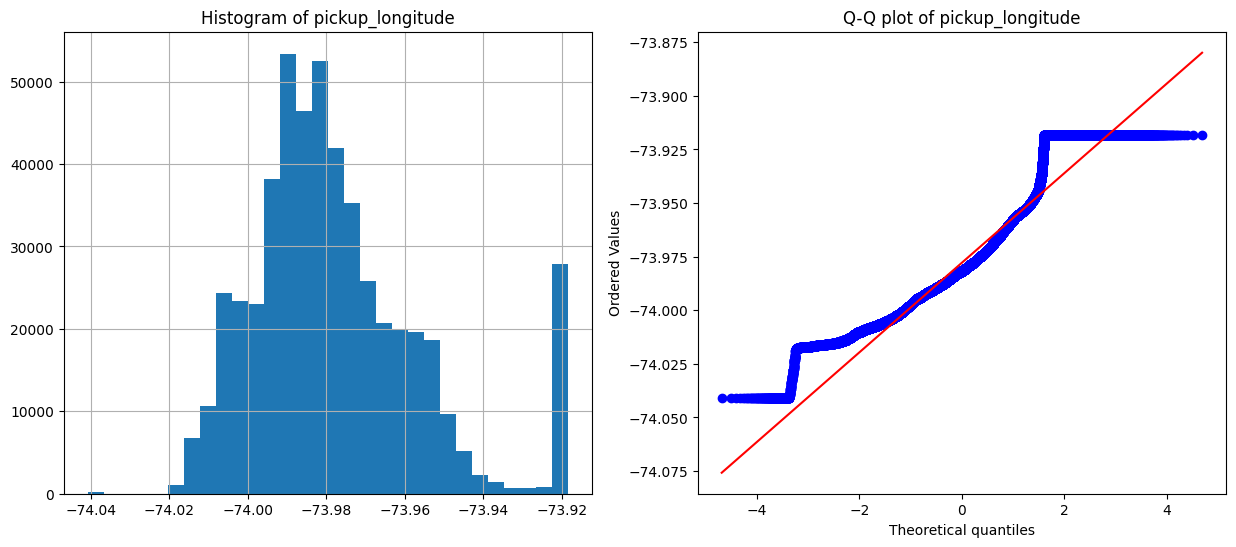

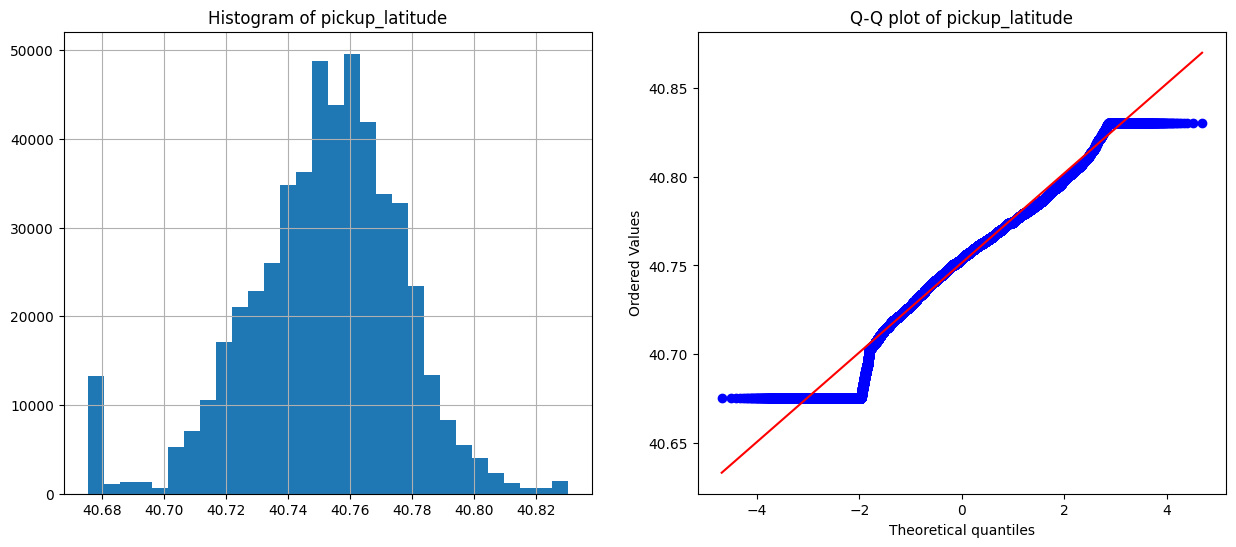

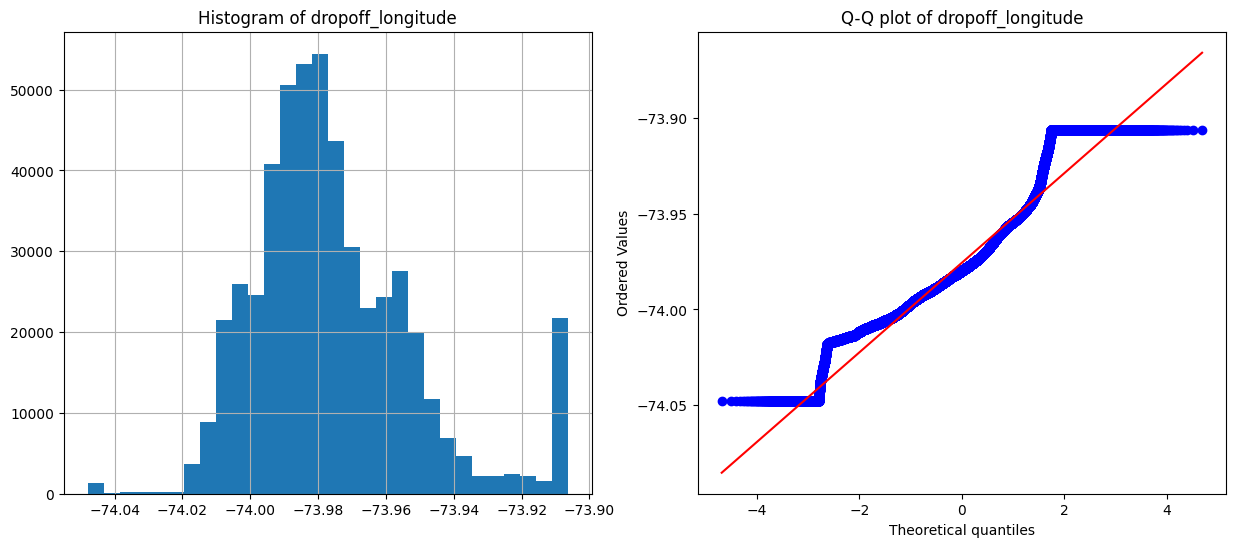

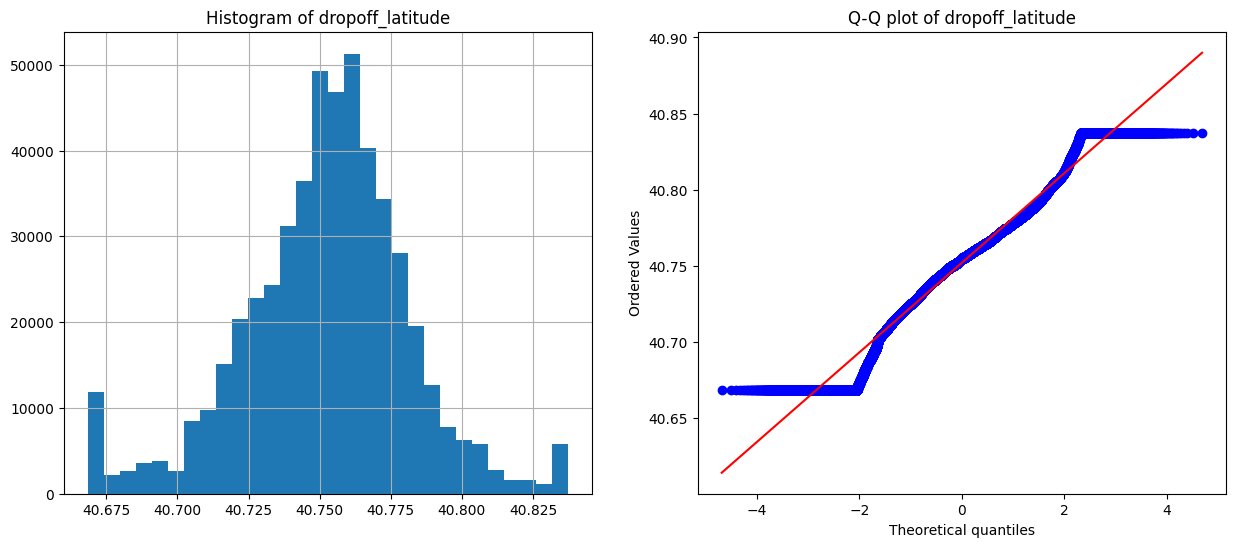

In [143]:
diagnostic_plots(X_train,'pickup_longitude')
diagnostic_plots(X_train,'pickup_latitude')
diagnostic_plots(X_train,'dropoff_longitude')
diagnostic_plots(X_train,'dropoff_latitude')

In [144]:
def make_kdeplot(df):

    plt.figure(figsize=(10, 6), constrained_layout=True)

    for i in range(4):

        # location in figure
        ax = plt.subplot(2, 3, i + 1)

        # variable to plot
        var = df.columns[i]

        # q-q plot
        sns.kdeplot(df[var])

        # add variable name as title
        ax.set_title(var)

    plt.show()

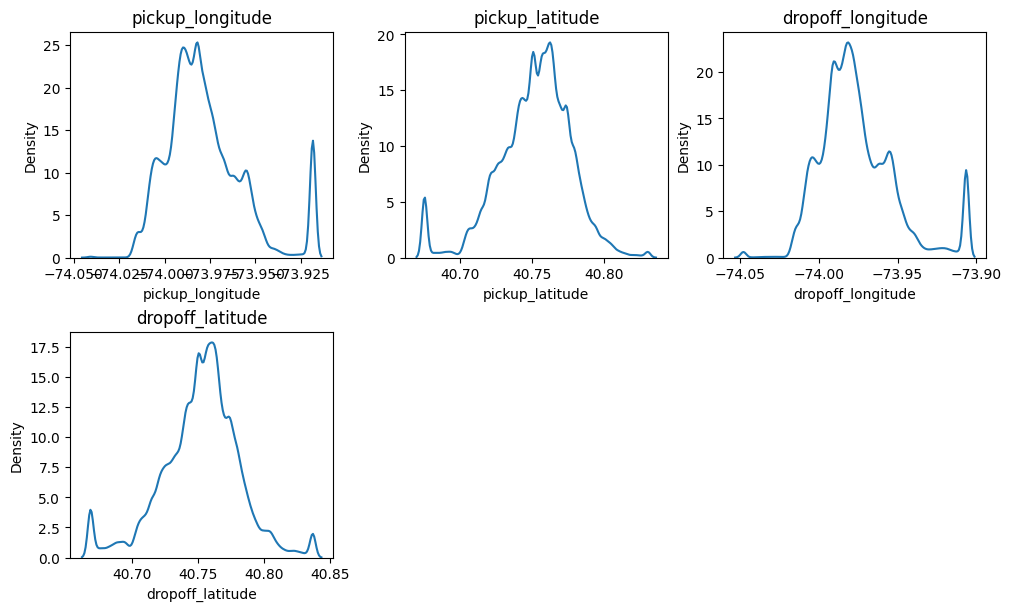

In [145]:
make_kdeplot(X_train[continuous])

Based on the spread and the concentrated range of latitude and longitude values, we need to apply variable transformation to it

In [ ]:
# !pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.1/364.1 kB 4.6 MB/s eta 0:00:00


Importing the libraries required to implement Linear Regression

In [157]:
from sklearn.linear_model import Lasso,LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# for feature engineering
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [147]:
!pip install feature_engine

In [170]:
from feature_engine import imputation as mdi
from feature_engine import discretisation as dsc
from feature_engine import encoding as ce
from sklearn.model_selection import KFold,cross_val_score

In [177]:
trip_duration_prediction_pipe = Pipeline([


    # categorical encoding - section 7-10

    ('categorical_enc', ce.OneHotEncoder(
        variables=categorical)),

    # discretisation + encoding - section 12


    # feature Scaling - section 18
    ('scaler', MinMaxScaler()),

    # regression
    ('lr', LinearRegression())
])



In [178]:
cv = KFold(n_splits=10)
scores = cross_val_score(trip_duration_prediction_pipe, X_train, y_train, cv = cv,scoring='r2')
scores.mean()

0.474374536700232

In [161]:
trip_duration_prediction_pipe.fit(X_train, y_train)

Pipeline(steps=[('categorical_enc', OneHotEncoder(variables=['Weekday_cat'])),
                ('scaler', MinMaxScaler()), ('lr', LinearRegression())])

In [162]:
# let's get the predictions
X_train_preds = trip_duration_prediction_pipe.predict(X_train)
X_test_preds = trip_duration_prediction_pipe.predict(X_test)

In [163]:
print('train mse: {}'.format(mean_squared_error(y_train, X_train_preds)))
print('train rmse: {}'.format(mean_squared_error(y_train, X_train_preds, squared=False)))
print('train r2: {}'.format(r2_score(y_train, X_train_preds)))
print()
print('test mse: {}'.format(mean_squared_error(y_test, X_test_preds)))
print('test rmse: {}'.format(mean_squared_error(y_test, X_test_preds, squared=False)))
print('test r2: {}'.format(r2_score(y_test, X_test_preds)))

train mse: 0.33077328876002066
train rmse: 0.5751289322925953
train r2: 0.4744157725750151

test mse: 0.33749500170674274
test rmse: 0.5809432000692862
test r2: 0.4698209033431505


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Text(0, 0.5, 'Predicted  Trip Duration')

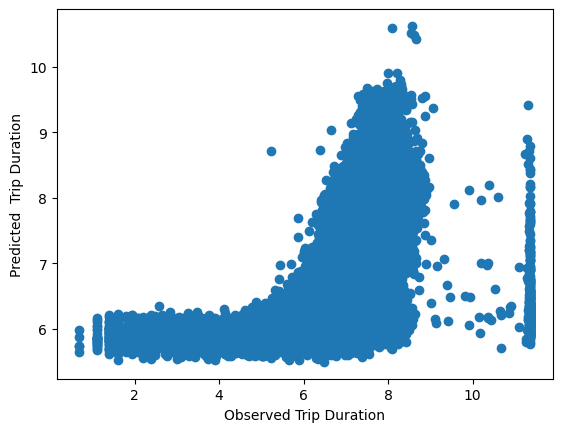

In [165]:
# plot predictions vs real value

plt.scatter(y_test,X_test_preds)
plt.xlabel('Observed Trip Duration')
plt.ylabel('Predicted  Trip Duration')